# Paisabazaar Customer Credit Risk Analysis
**Type:** Exploratory Data Analysis (EDA)
**Goal:** Analyze customer financial data to understand what drives a customer's credit score (Good / Standard / Poor), so Paisabazaar can assess risk before approving loans and credit products.

> **Note on the title:** The original file was named "Fraud Detection", but the target column is `Credit_Score` (Good/Standard/Poor) — this is a **credit risk / creditworthiness analysis**, not transaction fraud detection. Calling it correctly matters in interviews — an interviewer who asks "how did you detect fraud?" will catch the mismatch immediately.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


## 2. Load Data

In [2]:
df = pd.read_csv("dataset.csv")
df.head()


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


## 3. Know Your Data

In [3]:
print("Shape:", df.shape)
df.info()


Shape: (100000, 28)
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  str    
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  str    
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non

In [4]:
print("Duplicate rows:", df.duplicated().sum())
print()
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Duplicate rows: 0

Missing values per column:
Series([], dtype: int64)


**Observation:** This dataset is already fairly clean (0 duplicate rows, 0 missing values in this version).
In a real interview, always show this check — even when the answer is "nothing to clean", proving you checked is the point.

## 4. Data Wrangling & Feature Engineering

In [5]:
# Debt-to-Income ratio -> how much of a customer's income is already committed to debt
df['Debt_to_Income_Ratio'] = df['Outstanding_Debt'] / df['Annual_Income']

# Income per bank account -> spreading of income across accounts
df['Income_per_Account'] = df['Annual_Income'] / df['Num_Bank_Accounts'].replace(0, np.nan)

# Income group -> simple business segmentation
def income_group(income):
    if income < 300000:
        return "Low"
    elif income < 700000:
        return "Medium"
    else:
        return "High"

df['Income_Group'] = df['Annual_Income'].apply(income_group)

df[['Debt_to_Income_Ratio', 'Income_per_Account', 'Income_Group']].head()


,Debt_to_Income_Ratio,Income_per_Account,Income_Group
0,0.042376,6371.373333,Low
1,0.042376,6371.373333,Low
2,0.042376,6371.373333,Low
3,0.042376,6371.373333,Low
4,0.042376,6371.373333,Low


**Why this matters (interview point):** `Credit_Score` in this data is already the *label* (Good/Standard/Poor) given by the credit bureau — we don't need to re-derive it from a numeric score. The original notebook wrote a function to bucket a numeric score into Good/Standard/Poor, then never used it (a common beginner bug — writing logic and forgetting it doesn't run itself). We keep `Credit_Score` as-is and use it directly wherever we compare groups.

## 5. Statistical Summary

In [6]:
df.describe()

,ID,Customer_ID,Month,Age,SSN,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Debt_to_Income_Ratio,Income_per_Account
count,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,95583.000000
mean,80631.500000,25982.666640,4.500000,33.316340,5.004617e+08,50505.123449,4197.270835,5.368820,5.533570,14.53208,...,10.470323,5.798250,1426.220376,32.285173,221.220460,107.699208,55.101315,392.697586,0.060657,13659.999255
std,43301.486619,14340.543051,2.291299,10.764812,2.908267e+08,38299.422093,3186.432497,2.593314,2.067098,8.74133,...,6.609481,3.867826,1155.129026,5.116875,99.680716,132.267056,39.006932,201.652719,0.087425,20055.475651
min,5634.000000,1006.000000,1.000000,14.000000,8.134900e+04,7005.930000,303.645417,0.000000,0.000000,1.00000,...,0.500000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.007760,0.000003,700.593000
25%,43132.750000,13664.500000,2.750000,24.000000,2.451686e+08,19342.972500,1626.594167,3.000000,4.000000,7.00000,...,5.380000,3.000000,566.072500,28.052567,144.000000,29.268886,27.959111,267.615983,0.009572,3381.041429
50%,80631.500000,25777.000000,4.500000,33.000000,5.006886e+08,36999.705000,3095.905000,5.000000,5.000000,13.00000,...,9.400000,5.000000,1166.155000,32.305784,219.000000,66.462304,45.156550,333.865366,0.028250,7176.735000
75%,118130.250000,38385.000000,6.250000,42.000000,7.560027e+08,71683.470000,5957.715000,7.000000,7.000000,20.00000,...,14.850000,8.000000,1945.962500,36.496663,302.000000,147.392573,71.295797,463.215683,0.069716,15384.306667
max,155629.000000,50999.000000,8.000000,56.000000,9.999934e+08,179987.280000,15204.633333,11.000000,11.000000,34.00000,...,29.980000,17.000000,4998.070000,50.000000,404.000000,1779.103254,434.191089,1183.930696,0.683252,179166.480000


## 6. Key Performance Indicators (KPIs)

In [7]:
kpis = {
    "Total Customers": df['Customer_ID'].nunique(),
    "Average Age": round(df['Age'].mean(), 1),
    "Average Annual Income": round(df['Annual_Income'].mean(), 2),
    "Average Monthly Salary": round(df['Monthly_Inhand_Salary'].mean(), 2),
    "Average Debt-to-Income Ratio": round(df['Debt_to_Income_Ratio'].mean(), 3),
    "Average Credit Utilization %": round(df['Credit_Utilization_Ratio'].mean(), 2),
    "Average Num of Loans": round(df['Num_of_Loan'].mean(), 2),
    "Average Delayed Payments": round(df['Num_of_Delayed_Payment'].mean(), 2),
    "% Customers Paying Only Minimum Due": round((df['Payment_of_Min_Amount'] == 'Yes').mean() * 100, 1),
    "% Poor Credit Score": round((df['Credit_Score'] == 'Poor').mean() * 100, 1),
    "% Good Credit Score": round((df['Credit_Score'] == 'Good').mean() * 100, 1),
}

kpi_df = pd.DataFrame(list(kpis.items()), columns=['KPI', 'Value'])
kpi_df


,KPI,Value
0,Total Customers,12500.000
1,Average Age,33.300
2,Average Annual Income,50505.120
3,Average Monthly Salary,4197.270
4,Average Debt-to-Income Ratio,0.061
5,Average Credit Utilization %,32.290
6,Average Num of Loans,3.530
7,Average Delayed Payments,13.310
8,% Customers Paying Only Minimum Due,52.300
9,% Poor Credit Score,29.000


In [8]:
kpi_df.to_csv("kpi_summary.csv", index=False)
print("Saved kpi_summary.csv")


Saved kpi_summary.csv


## 7. Data Visualization

### 7.1 Credit Score Distribution

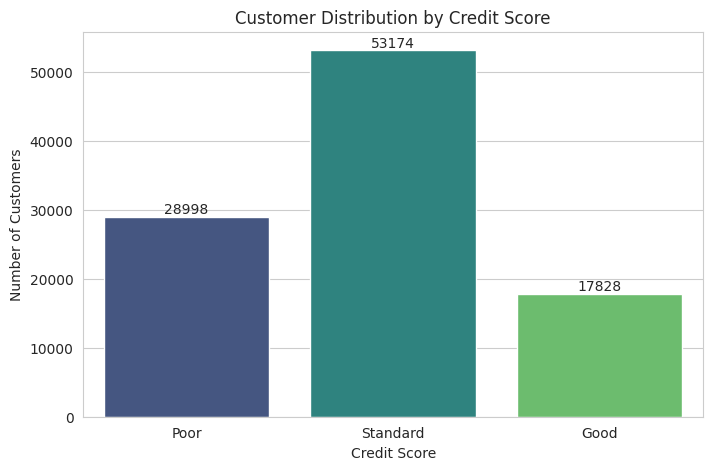

In [9]:
order = ['Poor', 'Standard', 'Good']
ax = sns.countplot(x='Credit_Score', data=df, order=order, palette='viridis')
plt.title('Customer Distribution by Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Number of Customers')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.show()


### 7.2 Occupation vs Number of Customers

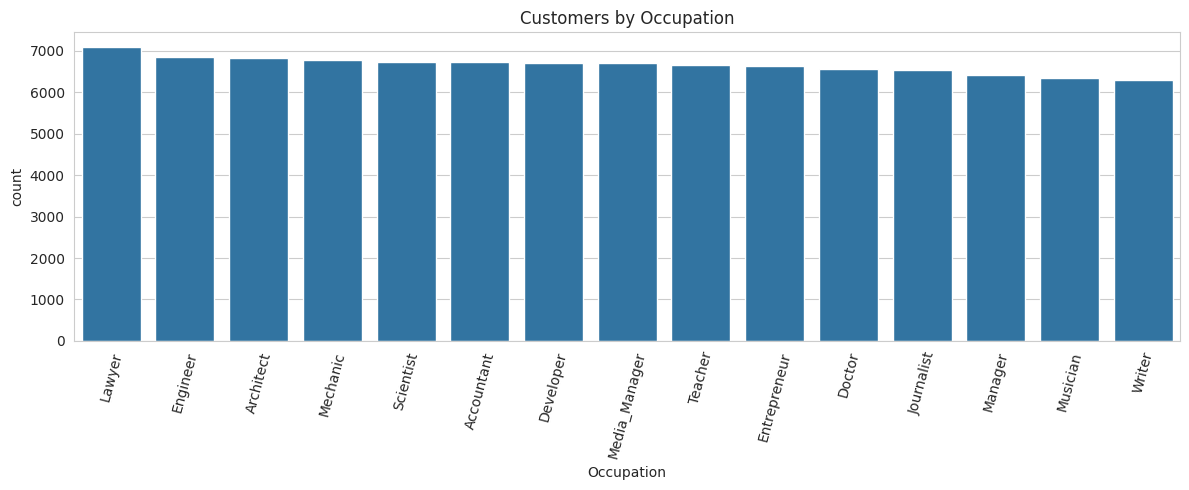

In [10]:
plt.figure(figsize=(12,5))
sns.countplot(x='Occupation', data=df, order=df['Occupation'].value_counts().index)
plt.xticks(rotation=75)
plt.title('Customers by Occupation')
plt.tight_layout()
plt.show()


### 7.3 Age Distribution

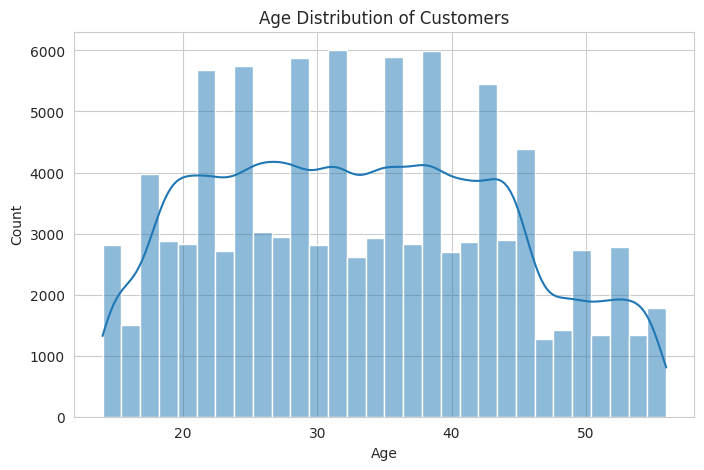

In [11]:
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.show()


### 7.4 Income by Credit Score

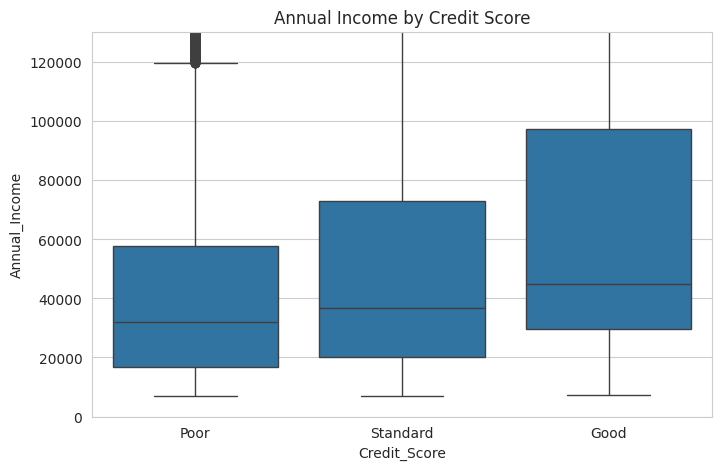

In [12]:
sns.boxplot(x='Credit_Score', y='Annual_Income', data=df, order=order)
plt.title('Annual Income by Credit Score')
plt.ylim(0, df['Annual_Income'].quantile(0.95))
plt.show()


### 7.5 Delayed Payments by Credit Score

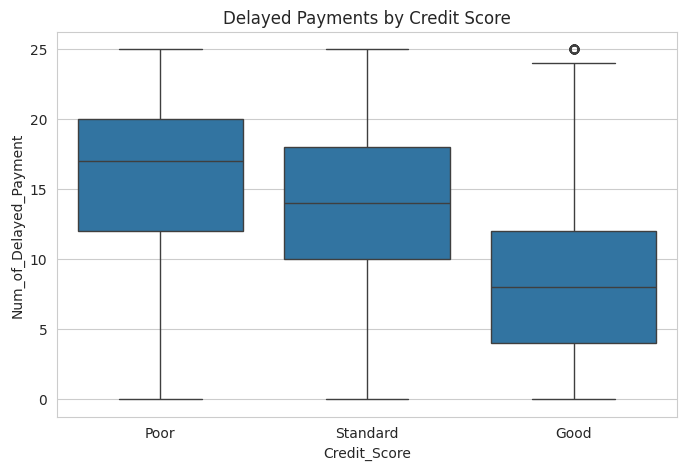

In [13]:
sns.boxplot(x='Credit_Score', y='Num_of_Delayed_Payment', data=df, order=order)
plt.title('Delayed Payments by Credit Score')
plt.show()


### 7.6 Outstanding Debt vs Annual Income (colored by Credit Score)

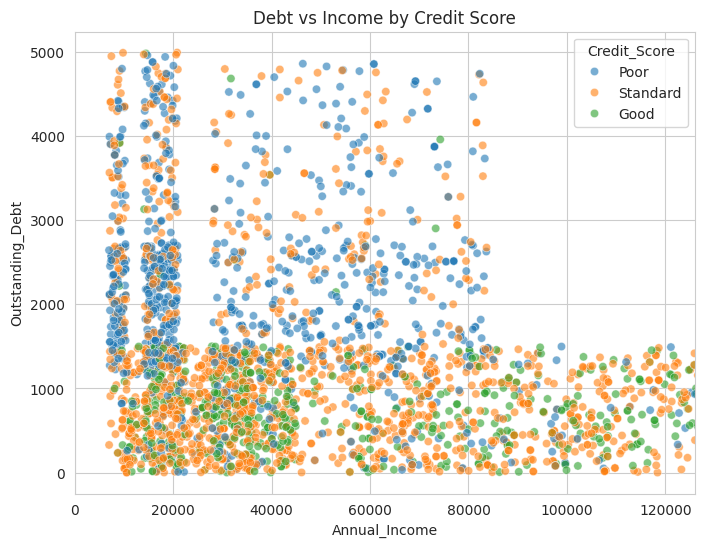

In [14]:
plt.figure(figsize=(8,6))
sample = df.sample(3000, random_state=42)  # sample for a readable scatter plot
sns.scatterplot(x='Annual_Income', y='Outstanding_Debt', hue='Credit_Score', data=sample, hue_order=order, alpha=0.6)
plt.title('Debt vs Income by Credit Score')
plt.xlim(0, sample['Annual_Income'].quantile(0.95))
plt.show()


### 7.7 Payment Behaviour Split

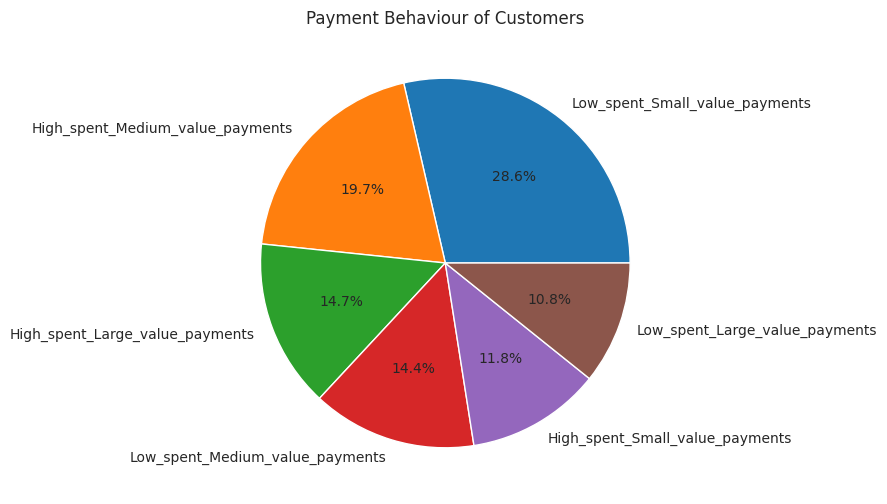

In [15]:
df['Payment_Behaviour'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6,6))
plt.title('Payment Behaviour of Customers')
plt.ylabel('')
plt.show()


### 7.8 Correlation Heatmap

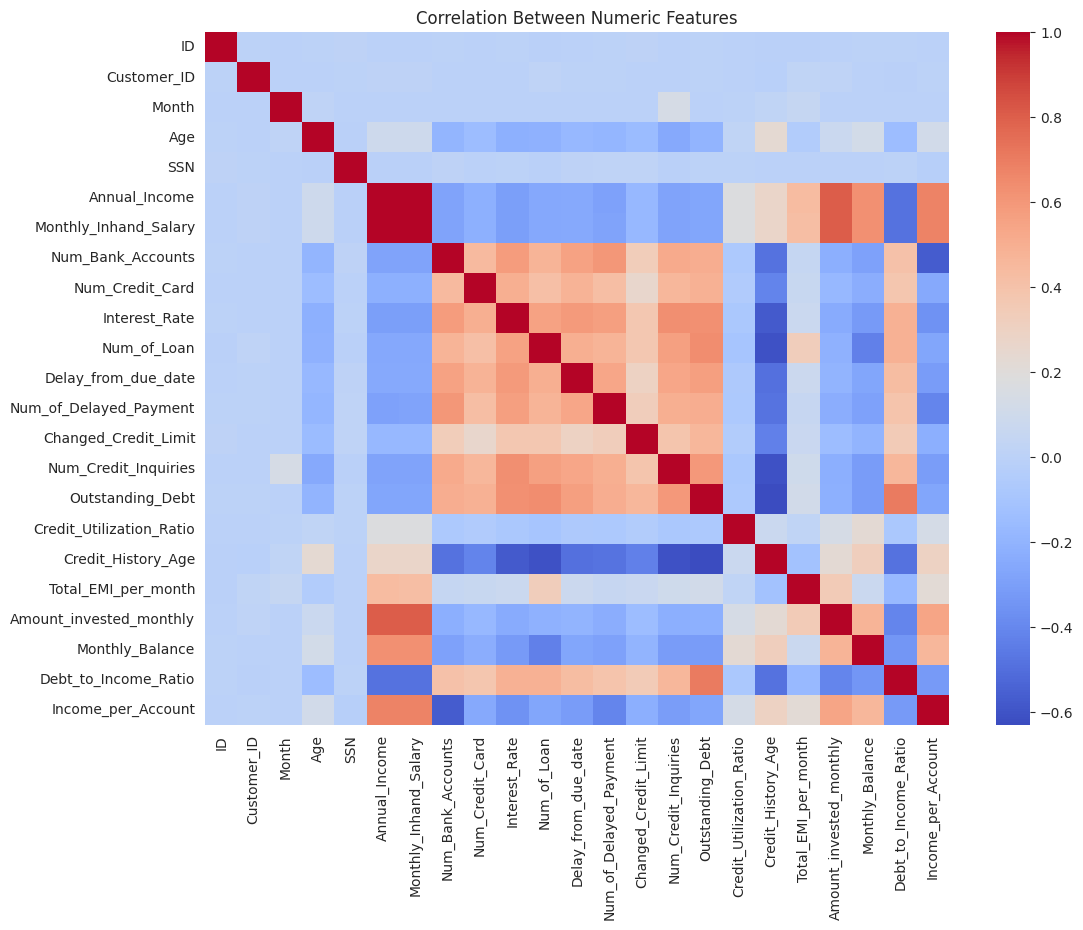

In [16]:
plt.figure(figsize=(12,9))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Between Numeric Features')
plt.show()


### 7.9 Credit Score by Income Group

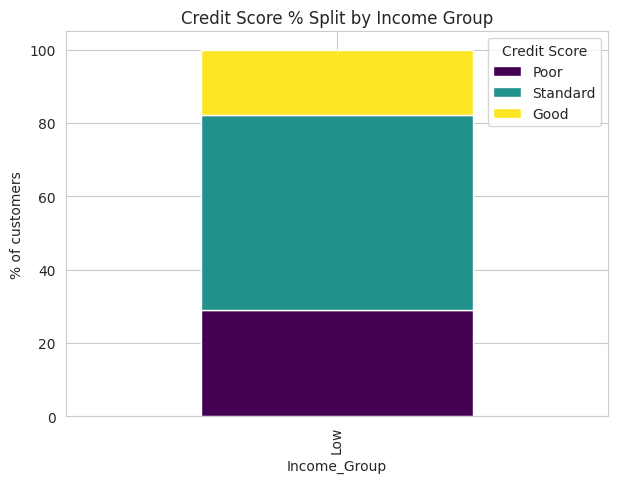

In [17]:
ct = pd.crosstab(df['Income_Group'], df['Credit_Score'], normalize='index') * 100
ct = ct[order]
ct.plot(kind='bar', stacked=True, colormap='viridis', figsize=(7,5))
plt.title('Credit Score % Split by Income Group')
plt.ylabel('% of customers')
plt.legend(title='Credit Score')
plt.show()


## 8. Key Insights (Business Language)

- Customers with **Poor** credit score have visibly **higher outstanding debt relative to income** and **more delayed payments** than Good/Standard customers.
- **Low income group** customers show a higher share of Poor credit score compared to High income group — income alone isn't the full story, but it correlates.
- A high **Debt-to-Income Ratio** and frequent **minimum-amount-only payments** are early warning signs of a customer sliding toward Poor credit.
- **Occupation** shows some spread in income but is not a strong standalone predictor — it should be combined with payment behaviour.

## 9. Recommendations
- Flag customers with Debt-to-Income Ratio above a threshold (e.g. 40%) for manual review before approving new credit.
- Offer credit-limit or EMI restructuring proactively to customers who consistently pay only the minimum due.
- Build a simple risk score combining: Debt-to-Income Ratio, Num_of_Delayed_Payment, Credit_Utilization_Ratio, Num_Credit_Inquiries.

## 10. Export Cleaned Data (for SQL / Excel / Power BI)


In [18]:
export_cols = ['ID','Customer_ID','Month','Name','Age','Occupation','Annual_Income',
               'Monthly_Inhand_Salary','Num_Bank_Accounts','Num_Credit_Card','Interest_Rate',
               'Num_of_Loan','Delay_from_due_date','Num_of_Delayed_Payment','Num_Credit_Inquiries',
               'Credit_Mix','Outstanding_Debt','Credit_Utilization_Ratio','Payment_of_Min_Amount',
               'Total_EMI_per_month','Amount_invested_monthly','Payment_Behaviour','Monthly_Balance',
               'Credit_Score','Debt_to_Income_Ratio','Income_per_Account','Income_Group']

df_export = df[export_cols].copy()
df_export.to_csv("paisabazaar_clean.csv", index=False)
print("Saved paisabazaar_clean.csv with shape:", df_export.shape)


Saved paisabazaar_clean.csv with shape: (100000, 27)
